In [1]:
# Configuration
TRIAL_NUMBER = 1  # Trial to analyze
TIME_BIN_SIZE = 0.05  # seconds (50 ms bins)

# Display options
SHOW_N_CHANNELS = 5  # Number of channels to display in plots
FIGURE_SIZE = (15, 10)  # Figure size for plots

# Spike channels (manually identified)
SPIKE_CHANNELS = [0, 1, 2, 3, 6, 32, 39, 40, 41, 42, 46, 49, 53, 67, 68, 73, 74, 75, 76, 77, 84]


In [2]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from neural_feature_extraction import NeuralFeatureExtractor, find_h5_file
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

print("✅ Setup complete!")


✅ Setup complete!


In [3]:
def load_and_extract_features(trial_number=TRIAL_NUMBER, time_bin_size=TIME_BIN_SIZE):
    """Load trial data and extract all neural features."""
    # Find H5 file
    h5_file = find_h5_file()
    if h5_file is None:
        print("❌ No H5 files found!")
        return None, None
    
    print(f"📁 Using H5 file: {h5_file}")
    
    # Initialize extractor
    extractor = NeuralFeatureExtractor(sampling_rate=30000)
    
    # Load trial data
    print(f"📂 Loading trial {trial_number}...")
    trial_data = extractor.load_trial_data(h5_file, trial_number)
    
    # Extract features
    print(f"🔍 Extracting features for {len(SPIKE_CHANNELS)} channels...")
    features = extractor.extract_all_features(
        trial_data['neural_data'], 
        SPIKE_CHANNELS, 
        time_bin_size
    )
    
    print("✅ Feature extraction complete!")
    return trial_data, features

# Load data
trial_data, features = load_and_extract_features()

if features is not None:
    print(f"\n📊 Data loaded successfully:")
    print(f"  • Neural data shape: {trial_data['neural_data'].shape}")
    print(f"  • Selected channels: {len(SPIKE_CHANNELS)}")
    print(f"  • Time bins: {len(features['spike_band']['time_axis'])}")
    print(f"  • Bin size: {TIME_BIN_SIZE*1000:.0f} ms")


📁 Using H5 file: development_archive\test_neural.h5
📂 Loading trial 1...
🔍 Extracting features for 21 channels...
🚀 Extracting features for 21 channels...
📊 Data shape: (21, 30000)
⏱️  Time bin size: 50 ms
🔍 Extracting spike band power (400-6000 Hz)...
✅ Spike band power extraction completed
🧠 Extracting LFP features (low-pass <250 Hz, gamma 30-100 Hz)...
✅ LFP feature extraction completed
⚡ Extracting voltage features (moving average and variance)...
✅ Voltage feature extraction completed
🎯 Extracting threshold crossings (-4x RMS)...


✅ Threshold crossing extraction completed
✅ Feature extraction complete!

📊 Data loaded successfully:
  • Neural data shape: (96, 30000)
  • Selected channels: 21
  • Time bins: 20
  • Bin size: 50 ms


In [4]:
def show_feature_summary(features):
    """Display a summary of all extracted features."""
    if features is None:
        print("❌ No features to display")
        return
    
    print("="*60)
    print("NEURAL FEATURE SUMMARY")
    print("="*60)
    
    # Get feature data
    spike_rms = features['spike_band']['rms_power']
    lfp_power = features['lfp']['lfp_power']
    gamma_power = features['lfp']['gamma_power']
    crossings = features['threshold']['crossing_counts']
    
    # Calculate statistics
    print(f"📊 Feature Statistics:")
    print(f"  • Spike RMS Power: {np.mean(spike_rms):.3f} ± {np.std(spike_rms):.3f}")
    print(f"  • LFP Power: {np.mean(lfp_power):.3f} ± {np.std(lfp_power):.3f}")
    print(f"  • Gamma Power: {np.mean(gamma_power):.3f} ± {np.std(gamma_power):.3f}")
    print(f"  • Total Crossings: {np.sum(crossings):.0f}")
    
    # Find most active channels
    spike_mean = np.mean(spike_rms, axis=1)
    crossing_sum = np.sum(crossings, axis=1)
    activity_score = spike_mean + crossing_sum/np.max(crossing_sum)*np.max(spike_mean)
    top_channels = np.argsort(activity_score)[-5:][::-1]
    
    print(f"\n🔥 Most active channels: {[SPIKE_CHANNELS[i] for i in top_channels]}")
    
    # Channel-wise statistics
    print(f"\n📈 Channel Statistics:")
    for i, ch in enumerate(SPIKE_CHANNELS[:5]):  # Show first 5 channels
        print(f"  • Channel {ch:2d}: Spike={spike_mean[i]:.3f}, Crossings={crossing_sum[i]:.0f}")

show_feature_summary(features)


NEURAL FEATURE SUMMARY
📊 Feature Statistics:
  • Spike RMS Power: 0.613 ± 0.018
  • LFP Power: 0.017 ± 0.004
  • Gamma Power: 0.005 ± 0.002
  • Total Crossings: 22

🔥 Most active channels: [74, 41, 46, 2, 42]

📈 Channel Statistics:
  • Channel  0: Spike=0.617, Crossings=1
  • Channel  1: Spike=0.613, Crossings=1
  • Channel  2: Spike=0.620, Crossings=2
  • Channel  3: Spike=0.620, Crossings=0
  • Channel  6: Spike=0.606, Crossings=0


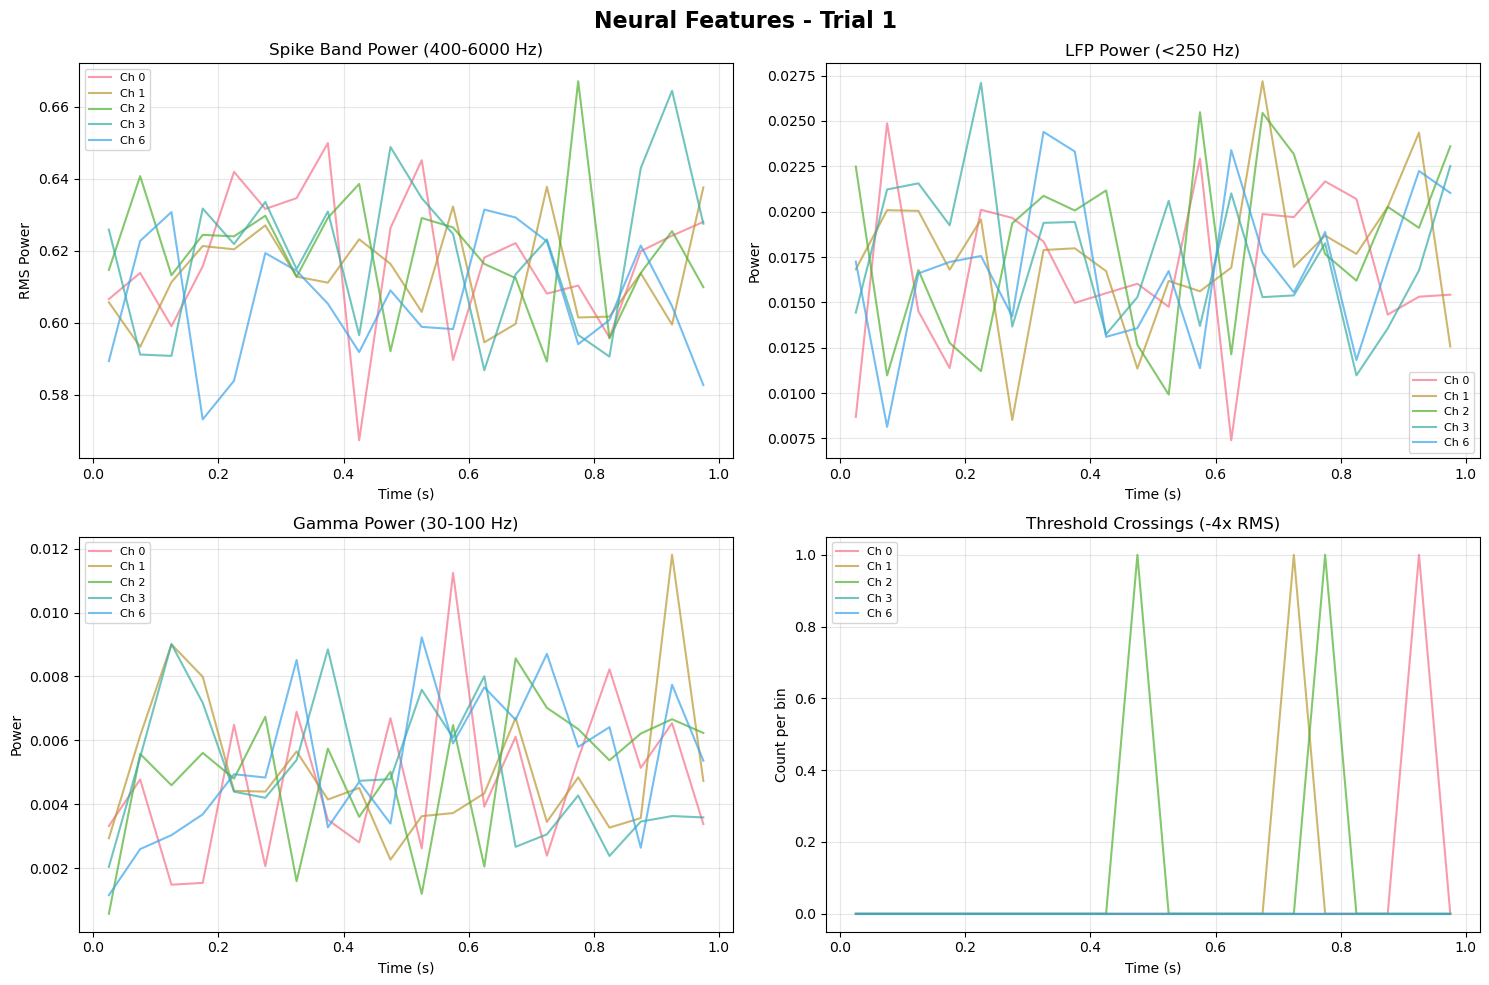

In [5]:
def quick_plot_features(features, n_channels=SHOW_N_CHANNELS, figsize=FIGURE_SIZE):
    """Create a quick visualization of the main features."""
    if features is None:
        print("❌ No features to plot")
        return
    
    # Get data
    time_axis = features['spike_band']['time_axis']
    spike_rms = features['spike_band']['rms_power']
    lfp_power = features['lfp']['lfp_power']
    gamma_power = features['lfp']['gamma_power']
    crossings = features['threshold']['crossing_counts']
    
    # Create figure
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    fig.suptitle(f'Neural Features - Trial {TRIAL_NUMBER}', fontsize=16, fontweight='bold')
    
    # Plot 1: Spike Band Power
    ax1 = axes[0, 0]
    for i in range(min(n_channels, len(SPIKE_CHANNELS))):
        ax1.plot(time_axis, spike_rms[i], label=f'Ch {SPIKE_CHANNELS[i]}', alpha=0.7)
    ax1.set_title('Spike Band Power (400-6000 Hz)')
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('RMS Power')
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: LFP Power
    ax2 = axes[0, 1]
    for i in range(min(n_channels, len(SPIKE_CHANNELS))):
        ax2.plot(time_axis, lfp_power[i], label=f'Ch {SPIKE_CHANNELS[i]}', alpha=0.7)
    ax2.set_title('LFP Power (<250 Hz)')
    ax2.set_xlabel('Time (s)')
    ax2.set_ylabel('Power')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Gamma Power
    ax3 = axes[1, 0]
    for i in range(min(n_channels, len(SPIKE_CHANNELS))):
        ax3.plot(time_axis, gamma_power[i], label=f'Ch {SPIKE_CHANNELS[i]}', alpha=0.7)
    ax3.set_title('Gamma Power (30-100 Hz)')
    ax3.set_xlabel('Time (s)')
    ax3.set_ylabel('Power')
    ax3.legend(fontsize=8)
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: Threshold Crossings
    ax4 = axes[1, 1]
    for i in range(min(n_channels, len(SPIKE_CHANNELS))):
        ax4.plot(time_axis, crossings[i], label=f'Ch {SPIKE_CHANNELS[i]}', alpha=0.7)
    ax4.set_title('Threshold Crossings (-4x RMS)')
    ax4.set_xlabel('Time (s)')
    ax4.set_ylabel('Count per bin')
    ax4.legend(fontsize=8)
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

quick_plot_features(features)


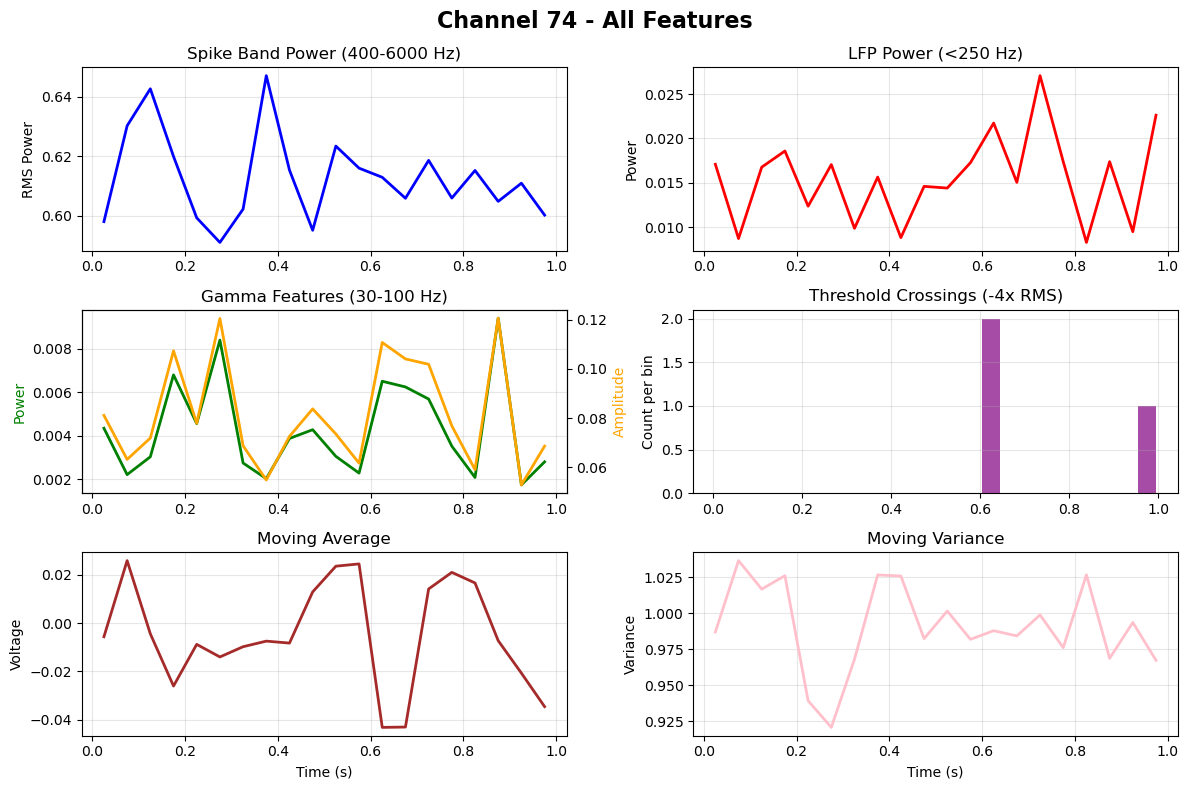


📊 Channel 74 Statistics:
  • Spike RMS Power: 0.613 ± 0.015
  • LFP Power: 0.016 ± 0.005
  • Gamma Power: 0.004 ± 0.002
  • Total Crossings: 3
  • Moving Average: -0.005 ± 0.021
  • Moving Variance: 0.991 ± 0.030


In [6]:
def explore_channel(features, channel_number, figsize=(12, 8)):
    """Explore all features for a specific channel."""
    if features is None:
        print("❌ No features to explore")
        return
    
    # Find channel index
    try:
        ch_idx = SPIKE_CHANNELS.index(channel_number)
    except ValueError:
        print(f"❌ Channel {channel_number} not in spike channels list")
        return
    
    # Get data
    time_axis = features['spike_band']['time_axis']
    spike_rms = features['spike_band']['rms_power'][ch_idx]
    lfp_power = features['lfp']['lfp_power'][ch_idx]
    gamma_power = features['lfp']['gamma_power'][ch_idx]
    gamma_amp = features['lfp']['gamma_amplitude'][ch_idx]
    crossings = features['threshold']['crossing_counts'][ch_idx]
    mov_avg = features['voltage']['moving_average'][ch_idx]
    mov_var = features['voltage']['moving_variance'][ch_idx]
    
    # Create figure
    fig, axes = plt.subplots(3, 2, figsize=figsize)
    fig.suptitle(f'Channel {channel_number} - All Features', fontsize=16, fontweight='bold')
    
    # Spike band power
    axes[0, 0].plot(time_axis, spike_rms, 'b-', linewidth=2)
    axes[0, 0].set_title('Spike Band Power (400-6000 Hz)')
    axes[0, 0].set_ylabel('RMS Power')
    axes[0, 0].grid(True, alpha=0.3)
    
    # LFP power
    axes[0, 1].plot(time_axis, lfp_power, 'r-', linewidth=2)
    axes[0, 1].set_title('LFP Power (<250 Hz)')
    axes[0, 1].set_ylabel('Power')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Gamma power and amplitude
    ax1 = axes[1, 0]
    ax1.plot(time_axis, gamma_power, 'g-', linewidth=2, label='Gamma Power')
    ax2 = ax1.twinx()
    ax2.plot(time_axis, gamma_amp, 'orange', linewidth=2, label='Gamma Amplitude')
    ax1.set_title('Gamma Features (30-100 Hz)')
    ax1.set_ylabel('Power', color='g')
    ax2.set_ylabel('Amplitude', color='orange')
    ax1.grid(True, alpha=0.3)
    
    # Threshold crossings
    axes[1, 1].bar(time_axis, crossings, width=TIME_BIN_SIZE*0.8, alpha=0.7, color='purple')
    axes[1, 1].set_title('Threshold Crossings (-4x RMS)')
    axes[1, 1].set_ylabel('Count per bin')
    axes[1, 1].grid(True, alpha=0.3)
    
    # Moving average
    axes[2, 0].plot(time_axis, mov_avg, 'brown', linewidth=2)
    axes[2, 0].set_title('Moving Average')
    axes[2, 0].set_xlabel('Time (s)')
    axes[2, 0].set_ylabel('Voltage')
    axes[2, 0].grid(True, alpha=0.3)
    
    # Moving variance
    axes[2, 1].plot(time_axis, mov_var, 'pink', linewidth=2)
    axes[2, 1].set_title('Moving Variance')
    axes[2, 1].set_xlabel('Time (s)')
    axes[2, 1].set_ylabel('Variance')
    axes[2, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print channel statistics
    print(f"\n📊 Channel {channel_number} Statistics:")
    print(f"  • Spike RMS Power: {np.mean(spike_rms):.3f} ± {np.std(spike_rms):.3f}")
    print(f"  • LFP Power: {np.mean(lfp_power):.3f} ± {np.std(lfp_power):.3f}")
    print(f"  • Gamma Power: {np.mean(gamma_power):.3f} ± {np.std(gamma_power):.3f}")
    print(f"  • Total Crossings: {np.sum(crossings):.0f}")
    print(f"  • Moving Average: {np.mean(mov_avg):.3f} ± {np.std(mov_avg):.3f}")
    print(f"  • Moving Variance: {np.mean(mov_var):.3f} ± {np.std(mov_var):.3f}")

# Example: Explore channel 74 (was identified as most active)
if features is not None:
    explore_channel(features, 74)


📚 Utility functions loaded!
Available functions:
  • save_features(features, filename)
  • load_saved_features(filename)
  • explore_different_trial(trial_number)
  • quick_channel_comparison(features, [ch1, ch2, ch3])
  • explore_channel(features, channel_number)

🔍 Comparing channels 74, 41, and 46:


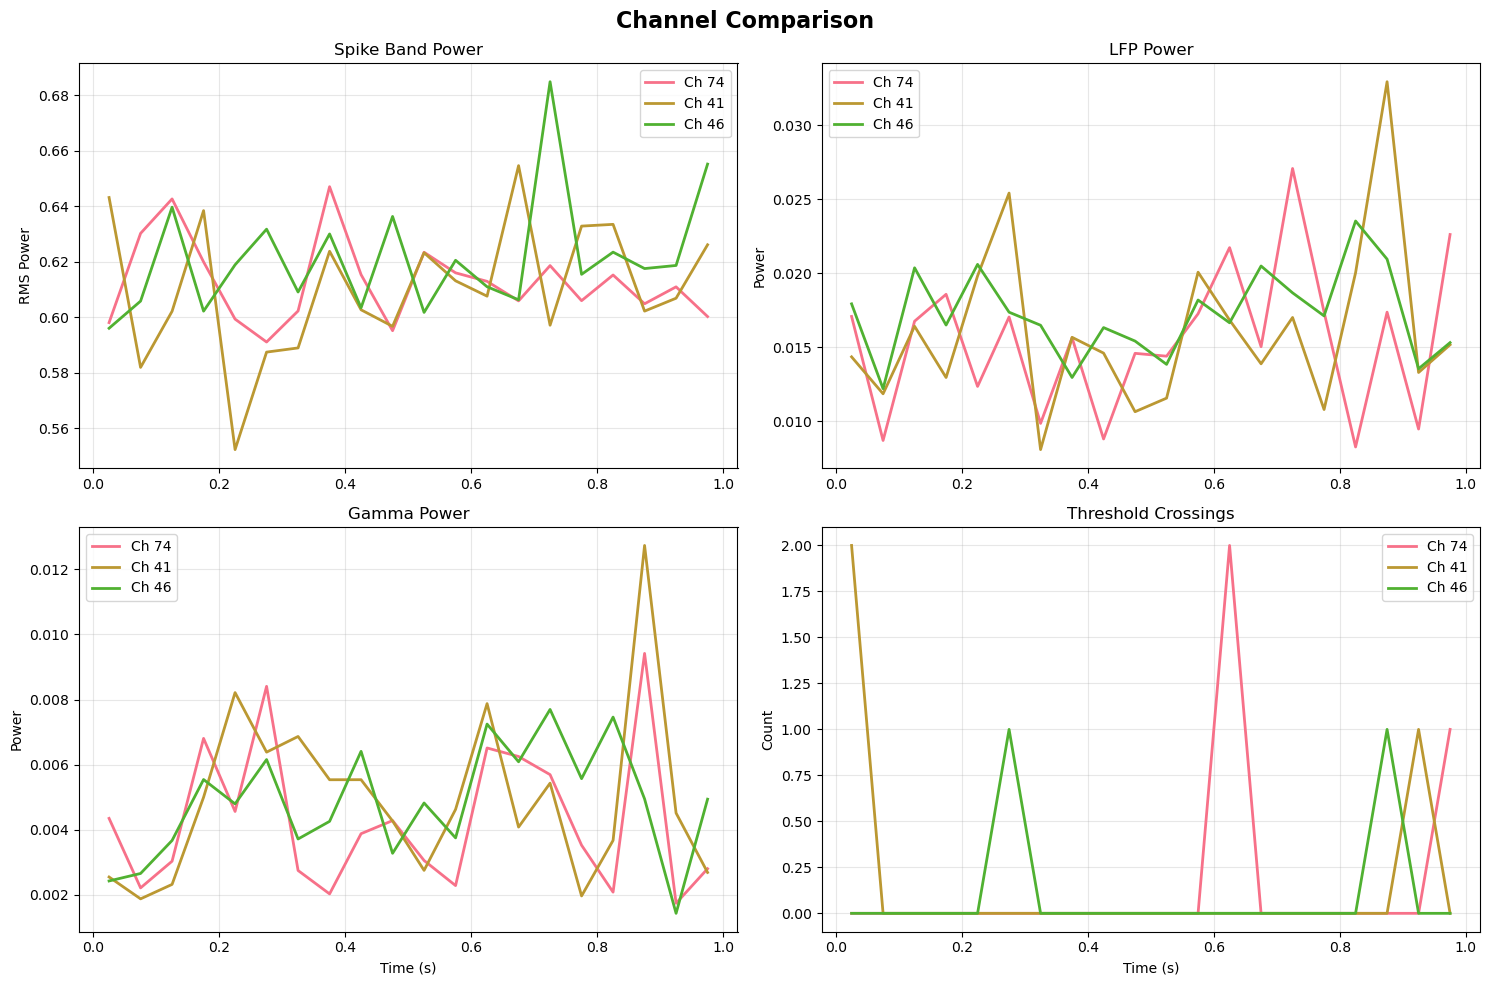

In [7]:
def save_features(features, filename=None):
    """Save extracted features to a NumPy file."""
    if features is None:
        print("❌ No features to save")
        return
    
    if filename is None:
        filename = f'neural_features_trial_{TRIAL_NUMBER:03d}.npz'
    
    np.savez_compressed(filename, **features)
    print(f"💾 Features saved to {filename}")

def load_saved_features(filename):
    """Load previously saved features."""
    try:
        loaded_features = np.load(filename, allow_pickle=True)
        
        # Convert back to dictionary format
        features_dict = {}
        for key in loaded_features.files:
            features_dict[key] = loaded_features[key].item() if loaded_features[key].ndim == 0 else loaded_features[key]
        
        print(f"📂 Loaded features from {filename}")
        return features_dict
    except FileNotFoundError:
        print(f"❌ File {filename} not found")
        return None

def explore_different_trial(trial_number):
    """Load and explore features from a different trial."""
    global TRIAL_NUMBER
    old_trial = TRIAL_NUMBER
    TRIAL_NUMBER = trial_number
    
    trial_data, features = load_and_extract_features(trial_number)
    
    if features is not None:
        print(f"\n🔍 Exploring Trial {trial_number}:")
        show_feature_summary(features)
        quick_plot_features(features)
    
    TRIAL_NUMBER = old_trial  # Reset to original
    return trial_data, features

def quick_channel_comparison(features, channels_to_compare):
    """Compare specific channels side by side."""
    if features is None:
        print("❌ No features to compare")
        return
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Channel Comparison', fontsize=16, fontweight='bold')
    
    time_axis = features['spike_band']['time_axis']
    
    for i, ch in enumerate(channels_to_compare):
        if ch not in SPIKE_CHANNELS:
            continue
            
        ch_idx = SPIKE_CHANNELS.index(ch)
        
        # Spike power
        axes[0, 0].plot(time_axis, features['spike_band']['rms_power'][ch_idx], 
                       label=f'Ch {ch}', linewidth=2)
        
        # LFP power  
        axes[0, 1].plot(time_axis, features['lfp']['lfp_power'][ch_idx], 
                       label=f'Ch {ch}', linewidth=2)
        
        # Gamma power
        axes[1, 0].plot(time_axis, features['lfp']['gamma_power'][ch_idx], 
                       label=f'Ch {ch}', linewidth=2)
        
        # Threshold crossings
        axes[1, 1].plot(time_axis, features['threshold']['crossing_counts'][ch_idx], 
                       label=f'Ch {ch}', linewidth=2)
    
    # Set titles and labels
    axes[0, 0].set_title('Spike Band Power')
    axes[0, 0].set_ylabel('RMS Power')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    axes[0, 1].set_title('LFP Power')
    axes[0, 1].set_ylabel('Power')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    axes[1, 0].set_title('Gamma Power')
    axes[1, 0].set_xlabel('Time (s)')
    axes[1, 0].set_ylabel('Power')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    axes[1, 1].set_title('Threshold Crossings')
    axes[1, 1].set_xlabel('Time (s)')
    axes[1, 1].set_ylabel('Count')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Example usage
print("📚 Utility functions loaded!")
print("Available functions:")
print("  • save_features(features, filename)")
print("  • load_saved_features(filename)")
print("  • explore_different_trial(trial_number)")
print("  • quick_channel_comparison(features, [ch1, ch2, ch3])")
print("  • explore_channel(features, channel_number)")

# Example: Compare a few interesting channels
if features is not None:
    print("\n🔍 Comparing channels 74, 41, and 46:")
    quick_channel_comparison(features, [74, 41, 46])
